In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))
from package import *

%load_ext autoreload
%autoreload 2


from tqdm import tqdm
import time


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader


import matplotlib.pyplot as plt


from IPython.display import clear_output, display

In [ ]:
sliding_windows = 0.

context_window = 128
batch_size = 64

d_emb = 512
nb_heads = 4
d_k = d_emb // nb_heads

mlp_multiplication=3

nb_layers = 8

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
#device = torch.device("cpu")
print(device)

mps


In [3]:
tokenizer = SingleCharTokenizer()
tokens = torch.tensor(tokenizer.load_tokens("../tokens_sc.tok"))
print(tokens.shape)


vocab_size = tokenizer.vocab_size
print("vocab_size : " , vocab_size)

dataset = TextDataset(tokens,context_window=context_window,sliding_windows=sliding_windows)
print("dataset_size : " ,len(dataset))


loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    num_workers = 2
)


torch.Size([11473626])
vocab_size :  65
dataset_size :  11473499


In [ ]:
gpt = GPT(  vocab_size=vocab_size,
            context_window=context_window,
            d_emb=d_emb,
            nb_layers=nb_layers,
            nb_heads=nb_heads, 
            mlp_multiplication=mlp_multiplication
            ).to(device)
gpt.architecture()

PARAMETERS :
embedding.E.weight: mps:0 torch.Size([65, 512]) 33280
embedding.P.weight: mps:0 torch.Size([128, 512]) 65536
transformer_blocks.0.norm1.weight: mps:0 torch.Size([512]) 512
transformer_blocks.0.norm1.bias: mps:0 torch.Size([512]) 512
transformer_blocks.0.norm2.weight: mps:0 torch.Size([512]) 512
transformer_blocks.0.norm2.bias: mps:0 torch.Size([512]) 512
transformer_blocks.0.attention.Wq.weight: mps:0 torch.Size([512, 512]) 262144
transformer_blocks.0.attention.Wk.weight: mps:0 torch.Size([512, 512]) 262144
transformer_blocks.0.attention.Wv.weight: mps:0 torch.Size([512, 512]) 262144
transformer_blocks.0.attention.Wo.weight: mps:0 torch.Size([512, 512]) 262144
transformer_blocks.0.feed_forward.NN.0.weight: mps:0 torch.Size([1536, 512]) 786432
transformer_blocks.0.feed_forward.NN.0.bias: mps:0 torch.Size([1536]) 1536
transformer_blocks.0.feed_forward.NN.2.weight: mps:0 torch.Size([512, 1536]) 786432
transformer_blocks.0.feed_forward.NN.2.bias: mps:0 torch.Size([512]) 512
tr

In [5]:
engine = Engine(gpt,tokenizer,device)
print(len(iter(loader)))

179273


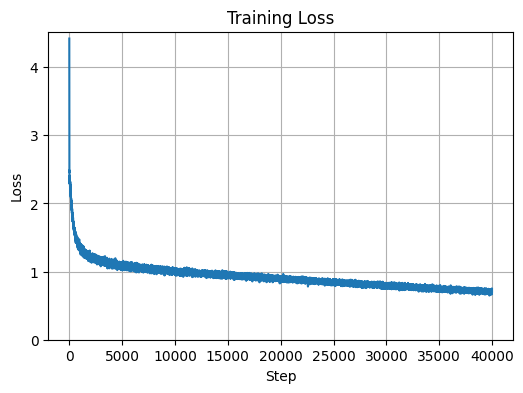

|----------------------------------------| 0/1 [16742.4s<0.0s, 0.0 it/s]
|███████████████████████████████████████-| 19990/20000 [16742.4s<8.4s, 1.2 it/s]
je pense que tout ce qui est vrai et verse 


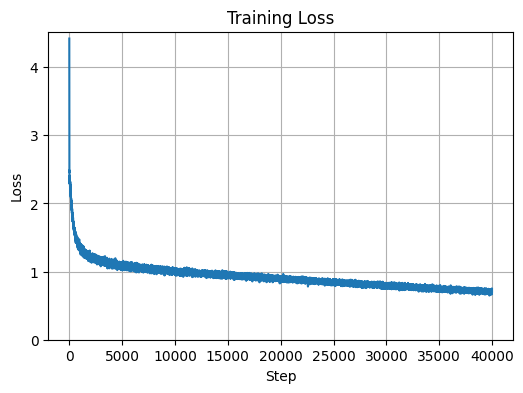

In [10]:
engine.train(loader,1,2000,20000,print_frequency=10)
engine.save_model("training_historic/final.w")


In [9]:
engine.save("training_historic/final.e")

In [ ]:
init = "bonjour, je m'appelle chateaubriand. je suis un homme de mon temps, j'ai connu les voyages, la revolutions et les cataclysmes politiques et je pense "

out = engine.generate(init,max_new_tokens=400,temperature=0.9,k=20)
print(out[128:])

litiques et je pense comme d'un peu d'eau. j'entre indignement quelques details sur la terre, je n'aurai jamais ete fait prisonnier par le merveilleux chretien : ce changement dans le genre d'attaque que je sais etre a l'humeur comme la plus illustre, presque sans flambeaux et sans paniers. le clerge s'abstenait de force avec le soleil, comme par ses couches tremblantes dans ses plaintes.
" il est si clair qu'elles etaient dessechees par l'ecriture qu'un titre et un grand chien de l'atlas etaient couvert de maison et qu'avec des buffles d'airain une mort laide et feroce, et allant a la fraicheur de l'avarice et la colere du desert, a la consolation de cette cour ; elle verra mes quenouilles vers l'astre du jour ; mais elle sera a paris a trieste.
n'est-ce pas une grande affaire d'autant plus decedee ? cela sera avant qu'il y en ait tout a fait d'abord, il me semble, comment, dans mon ame et mes confreres. je demanderai au parlement quel sujet m'a donne bonheur ou retombera malade ; p